# Polynomial Regression

What if your data is more complex than a straight line &rarr; you can still use a linear model to fit nonlinear data. Simple way to do so is to add powers of each feature as new features, then train a linear model on this extended set of features. This technique is called *Polynomial Regression*

*Polynomial regression* is a regression analysis method that model the relationship between an independent variable $X$ and a dependent variable $y$ as an $n-th$ degreee polynomila

---

### How It Works
- **Curved fit**: it fits a curved line to data that does not follow a straight path
- **General Formula**: $y = \beta_0 + \beta_1X + \beta_2X^2 + \dots + \beta_nX^n$
- **Still Linear**: it is considered a linear model because it is linear in the unknown coefficients ($\beta$ values)

---

#### Why Use It
- **Non-linear data**: simple linear regression fails when data points form a curve
- **Flexibility** higher degrees capture complex pattenrs like rapid growth or U-shapes
---

In [174]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression,SGDRegressor

from sklearn.preprocessing import PolynomialFeatures,StandardScaler

from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

In [175]:
# Generate nonlinear data
m = 100
X =  6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

|Data Generatoin|
|:-------------:|
|A quadratic equation is of the form $y = ax^2 + bx + c$

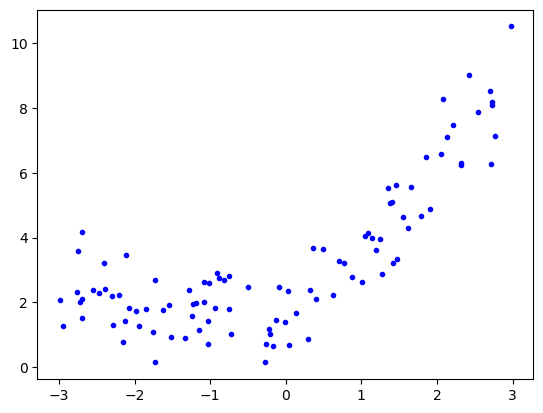

In [176]:
plt.plot(X, y, 'b.')
plt.show()

In [177]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2)

In [178]:
X_train.shape

(80, 1)

### Applying Linear Regression

In [179]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2_score(y_test, y_pred)

0.6322685528889703

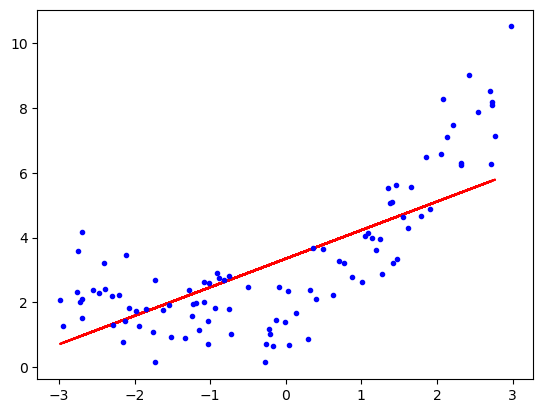

In [180]:
plt.plot(X_train, model.predict(X_train), color = 'r')
plt.plot(X,y,'b.')

plt.show()

### Applying Polynomial Regression

In [181]:
poly_features = PolynomialFeatures(degree = 2, include_bias = True)


X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

In [182]:
X_train[0], X_train_poly[0]

(array([-1.23921433]), array([ 1.        , -1.23921433,  1.53565217]))

In [183]:
model = LinearRegression()
model.fit(X_train_poly, y_train)

y_pred = model.predict(X_test_poly)
r2_score(y_test, y_pred)

0.9135821922995979

In [184]:
model.intercept_

array([2.11200336])

In [185]:
model.coef_

array([[0.        , 1.04489342, 0.42980108]])

In [186]:
X_unseen = np.linspace(-3, 3, 200).reshape(200, 1)
X_unseen_poly = poly_features.transform(X_unseen)
y_unseen = model.predict(X_unseen_poly)

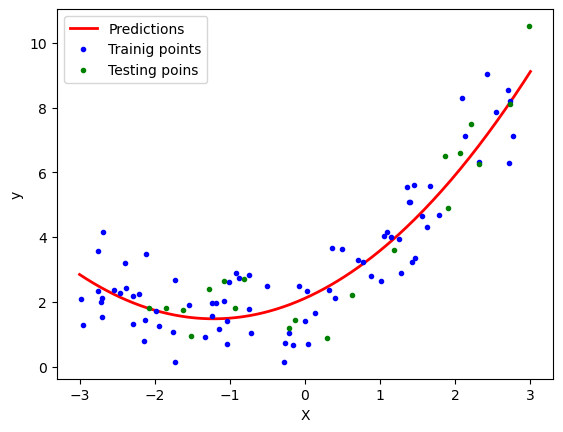

In [187]:
plt.plot(X_unseen, y_unseen, 'r-', linewidth = 2, label = 'Predictions')
plt.plot(X_train, y_train, 'b.', label = 'Trainig points')
plt.plot(X_test, y_test, 'g.', label = 'Testing poins')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()

plt.show()

|<font style = 'color:#F2765E'>NOTE</font>|
|:---------------------------------------:|
|When there are multiple features, Polynomial Regression is capable of finding relationships between features (which is something a plain Linear Regression model cannot do)|

|<font style = 'color:#800020'>NOTICE</font>|
|:---------------------------------------:|
|PolynomialFeatures(degree = d) transform an array conatainig $n$ features into an array containing $(n + d)! / d!n!$ features, where $n!$ is the factorial of $n$, equal to $1 \times 2 \times 3 \times \dots \times n$. Beware of the combinational explosion of the number of features!|

You rarely know the exact mathematical function that generated your data. Because of this, a simple model might underfit (miss patterns) and a high-degree model might overfit (memorize noise), making it hard to choose the perfect complexity.

|<font style = 'color:#F2765E'>IMPORTANT</font>|
|:---------------------------------------:|
|You rarely know the exact mathematical function that generated your data. Because of this, a simple model might underfit (miss patterns) and a high-degree model might overfit (memorize noise), making it hard to choose the perfect complexity.|
|Method 1: Cross-Validation Metrics
You can judge your model by comparing its performance on training data versus a cross-validation dataset:
Overfitting: The model scores very well on the training data but poorly on the validation metrics.
Underfitting: The model scores poorly on both the training data and validation metrics.|
|Method 2: Learning Curves
Learning curves are graphs that plot the model's performance on both the training set and the validation set as the size of the training data grows.
How they are made: You train the model multiple times, starting with a tiny subset of the data and gradually increasing the dataset size.
The Goal: Watching how the training and validation errors behave as data scales reveals whether the model is too simple or too complex.|

In [188]:
def polynomial_regression(degree):
    X_new = np.linspace(-3, 3, 100).reshape(100, 1)
    X_new_poly = poly_features.transform(X_new)

    lin_reg = LinearRegression()

    polynomial_regression = Pipeline([
        ('poly_features', PolynomialFeatures(degree = degree, include_bias = False)),
        ('std_scaler', StandardScaler()),
        ('lr_model', LinearRegression())
    ])

    polynomial_regression.fit(X, y)
    y_new_big = polynomial_regression.predict(X_new)

    plt.plot(X_new, y_new_big, 'r', label = 'Degree' + str(degree), linewidth = 2)

    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])

    
    plt.show()

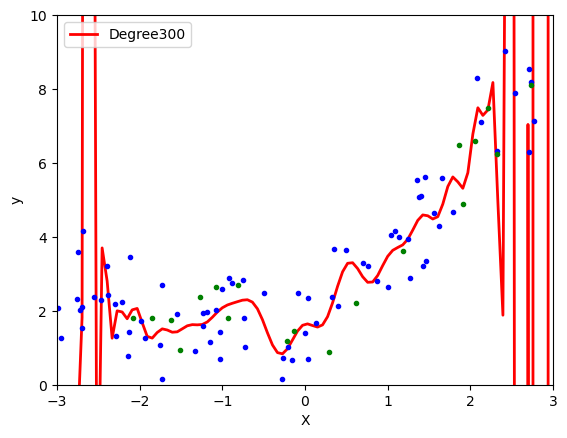

In [189]:
polynomial_regression(300)

### 3D Polynomial Regression

In [190]:
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y +2 + np.random.randn(100, 1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

In [191]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df, x = x.ravel(), y = y.ravel(), z = z.ravel())
fig.show()

In [192]:
lr = LinearRegression()
lr.fit(np.array([X,y]).reshape(100, 2), z)

x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input, y_input)

final = np.vstack((xGrid.ravel().reshape(1, 100), yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)

In [193]:
import plotly.graph_objects as go
fig = px.scatter_3d(df, x = x.ravel(), y = y.ravel(), z = z.ravel())
fig.add_trace(go.Surface(x = x_input, y = y_input, z = z_final))

fig.show()

In [194]:
X_multi = np.array([X,y]).reshape(100,2)
X_multi.shape

(100, 2)

In [195]:
poly = PolynomialFeatures(degree = 2)
X_multi_trans = poly.fit_transform(X_multi)

In [196]:
poly.n_features_in_

2

In [197]:
poly.n_output_features_

6

In [198]:
poly.powers_

array([[0, 0],
       [1, 0],
       [0, 1],
       [2, 0],
       [1, 1],
       [0, 2]])

In [199]:
X_multi_trans.shape

(100, 6)

In [200]:
lr = LinearRegression()
lr.fit(X_multi_trans, z)

LinearRegression()

In [201]:
X_test_multi = poly.transform(final)

In [202]:
z_final = lr.predict(X_multi_trans).reshape(10,10)

In [203]:
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final))

fig.update_layout(scene = dict(zaxis = dict(range=[0,35])))

fig.show()

#### Learning Curves

In [204]:
from sklearn.metrics import mean_squared_error

def learning_cureves(model, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2)

    train_errors, val_errors = [], []

    for i in range(1, len(X_train)):
        model.fit(X_train[:i], y_train[:i])
        y_train_predict = model.predict(X_train[:i])
        y_val_predict = model.predict(X_val[:i])

        train_errors.append(mean_squared_error(y_train[:i], y_train_predict))
        val_errors.append(mean_squared_error(y_val[:i], y_val_predict))
    plt.plot(np.sqrt(train_errors), 'r-+', linewidth = 2, label = 'train')
    plt.plot(np.sqrt(val_errors), 'b-', linewidth = 2, label = 'val')
    plt.grid(True)

    plt.legend()

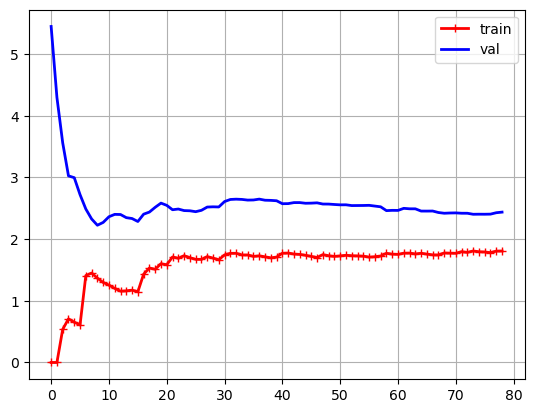

In [205]:
lin_reg = LinearRegression()
learning_cureves(lin_reg, X, y)

|<font style = 'color:#F2765E'>NOTE</font>|
|:---------------------------------------:|
|If your model is underfitting the training data, adding more training examples will not help. You need to use a more complex model or come up with better features|

In [206]:
polynomial_regression = Pipeline([
    ('poly_features', PolynomialFeatures(degree = 10, include_bias = False)),
    ('lin_reg', LinearRegression())
])

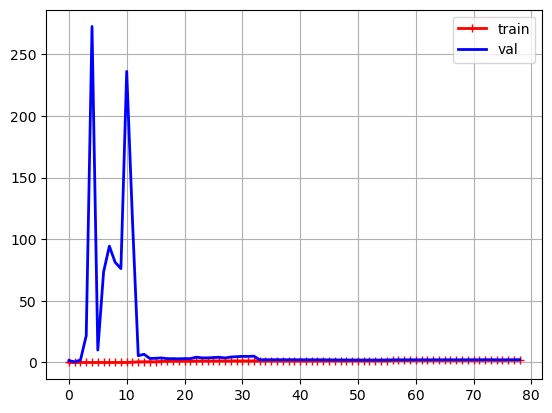

In [207]:
learning_cureves(polynomial_regression, X, y)

|<font style = 'color:#F2765E'>NOTE</font>|
|:---------------------------------------:|
|One way to improve an overfitting model is to feed it more training data until the validation error reaches the training error|

### Applying Gradient Descent

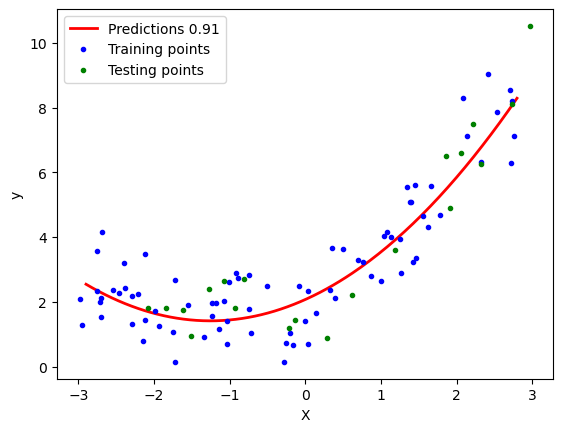

In [209]:
poly = PolynomialFeatures(degree = 2)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

stoch_gd = SGDRegressor(max_iter = 100)
stoch_gd.fit(X_train_trans, y_train)

X_new=np.linspace(-2.9, 2.8, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = stoch_gd.predict(X_new_poly)

plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions " + str(round(r2_score(y_test,y_pred),2)))
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()